# PBS Multi Measure

여러 PBS CSV에서 시간별 Vth를 계산하고, 각 데이터의 Delta Vth vs time을 한 그래프에 겹쳐 그립니다.

In [13]:
import csv
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from IPython.display import display

plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.grid'] = True


In [14]:
# CSV path 입력
# path1~3 : Vg=2.2V, Vd=0V
# path4~6 : Vg=2.2V, Vd=1V
# path7~9 : Vg=2.2V, Vd=2V

path1 = "PBTI_IGZO_new2 [260331_WF02_#4_MID_UNITTR_PBS_VG2.2V_VD0V_R0(10) ; 4_16_2026 9_23_10 AM].csv"
path2 = "PBTI_IGZO_new2 [260331_WF02_#4_MID_UNITTR_PBS_VG2.2V_VD0V_R1(11) ; 4_16_2026 10_00_03 AM].csv"
path3 = "PBTI_IGZO_new2 [260331_WF02_#4_MID_UNITTR_PBS_VG2.2V_VD0V_R2(12) ; 4_16_2026 10_35_54 AM].csv"

path4 = "PBTI_IGZO_new2 [260331_WF02_#4_MID_UNITTR_PBS_VG2.2V_VD1V_R3(13) ; 4_16_2026 11_17_48 AM].csv"
path5 = "PBTI_IGZO_new2 [260331_WF02_#4_MID_UNITTR_PBS_VG2.2V_VD1V_R4(14) ; 4_16_2026 12_27_06 PM].csv"
path6 = "PBTI_IGZO_new2 [260331_WF02_#4_MID_UNITTR_PBS_VG2.2V_VD1V_R5(15) ; 4_16_2026 1_17_53 PM].csv"

path7 = "PBTI_IGZO_new2 [260331_WF02_#4_MID_UNITTR_PBS_VG2.2V_VD2V_R6(16) ; 4_16_2026 2_18_45 PM].csv"
path8 = "PBTI_IGZO_new2 [260331_WF02_#4_MID_UNITTR_PBS_VG2.2V_VD2V_R7(17) ; 4_16_2026 2_55_05 PM].csv"
path9 = "PBTI_IGZO_new2 [260331_WF02_#4_MID_UNITTR_PBS_VG2.2V_VD2V_R8(18) ; 4_16_2026 3_31_53 PM].csv"

dataset_infos = [
    {"path": path1, "vg": 2.2, "vd": 0, "data_idx": 1},
    {"path": path2, "vg": 2.2, "vd": 0, "data_idx": 2},
    {"path": path3, "vg": 2.2, "vd": 0, "data_idx": 3},
    {"path": path4, "vg": 2.2, "vd": 1, "data_idx": 1},
    {"path": path5, "vg": 2.2, "vd": 1, "data_idx": 2},
    {"path": path6, "vg": 2.2, "vd": 1, "data_idx": 3},
    {"path": path7, "vg": 2.2, "vd": 2, "data_idx": 1},
    {"path": path8, "vg": 2.2, "vd": 2, "data_idx": 2},
    {"path": path9, "vg": 2.2, "vd": 2, "data_idx": 3},
]

for info in dataset_infos:
    info["label"] = f"Vg={info['vg']}[V], Vd={info['vd']}[V] data{info['data_idx']}"

dataset_infos


[{'path': 'PBTI_IGZO_new2 [260331_WF02_#4_MID_UNITTR_PBS_VG2.2V_VD0V_R0(10) ; 4_16_2026 9_23_10 AM].csv',
  'vg': 2.2,
  'vd': 0,
  'data_idx': 1,
  'label': 'Vg=2.2[V], Vd=0[V] data1'},
 {'path': 'PBTI_IGZO_new2 [260331_WF02_#4_MID_UNITTR_PBS_VG2.2V_VD0V_R1(11) ; 4_16_2026 10_00_03 AM].csv',
  'vg': 2.2,
  'vd': 0,
  'data_idx': 2,
  'label': 'Vg=2.2[V], Vd=0[V] data2'},
 {'path': 'PBTI_IGZO_new2 [260331_WF02_#4_MID_UNITTR_PBS_VG2.2V_VD0V_R2(12) ; 4_16_2026 10_35_54 AM].csv',
  'vg': 2.2,
  'vd': 0,
  'data_idx': 3,
  'label': 'Vg=2.2[V], Vd=0[V] data3'},
 {'path': 'PBTI_IGZO_new2 [260331_WF02_#4_MID_UNITTR_PBS_VG2.2V_VD1V_R3(13) ; 4_16_2026 11_17_48 AM].csv',
  'vg': 2.2,
  'vd': 1,
  'data_idx': 1,
  'label': 'Vg=2.2[V], Vd=1[V] data1'},
 {'path': 'PBTI_IGZO_new2 [260331_WF02_#4_MID_UNITTR_PBS_VG2.2V_VD1V_R4(14) ; 4_16_2026 12_27_06 PM].csv',
  'vg': 2.2,
  'vd': 1,
  'data_idx': 2,
  'label': 'Vg=2.2[V], Vd=1[V] data2'},
 {'path': 'PBTI_IGZO_new2 [260331_WF02_#4_MID_UNITTR_PBS_VG2.

In [15]:
def load_pbs_csv(path):
    rows = []
    with open(path, "r", encoding="utf-8-sig", errors="replace", newline="") as f:
        reader = csv.reader(f)
        for row in reader:
            rows.append(row)

    max_len = max(len(row) for row in rows)
    rows = [row + [""] * (max_len - len(row)) for row in rows]
    raw_data = pd.DataFrame(rows)

    is_datavalue = raw_data[0].isin(["DataValue"])
    raw_data = raw_data[is_datavalue].copy()
    raw_data = raw_data.iloc[:, 1:6]
    raw_data.columns = ["Vgate", "Vdrain", "Idrain", "IdMax", "Vth@Id"]

    df = raw_data.copy()
    time_series = df.loc[df["Idrain"].isin([" "]), "Vgate"]
    time_list = list(reversed(time_series.tolist()))
    time_count = len(time_list)
    df = df.iloc[time_count:, :].copy()

    df["IdMax"] = pd.to_numeric(df["IdMax"], errors="coerce")
    df["block"] = df["IdMax"].notna().cumsum()
    df = df[df["block"] > 0].copy()

    mapping = {i + 1: t for i, t in enumerate(time_list)}
    df["time_s"] = df["block"].map(mapping)

    df["Vgate"] = pd.to_numeric(df["Vgate"], errors="coerce")
    df["Vdrain"] = pd.to_numeric(df["Vdrain"], errors="coerce")
    df["Idrain"] = pd.to_numeric(df["Idrain"], errors="coerce").abs()
    df["time_s"] = pd.to_numeric(df["time_s"], errors="coerce")

    return df.dropna(subset=["Vgate", "Idrain", "time_s"]).copy()


W_um = 40
L_um = 20
W_over_L = W_um / L_um
L_m = L_um * 1e-6
Cox_total_F = 4.25e-12

def extract_vth_by_time(df, target_log_id=-10):
    vth_by_time = {}

    for time_s, group in df.groupby("time_s"):
        group = group.sort_values("Vgate")
        vg = group["Vgate"].to_numpy()
        idrain = group["Idrain"].to_numpy()

        abs_id = np.clip(np.abs(idrain), 1e-300, None)
        norm_id = abs_id / W_over_L
        log_i = np.log10(norm_id)
        diff = log_i - target_log_id
        cross_idx = np.where(diff[:-1] * diff[1:] <= 0)[0]

        if len(cross_idx) == 0:
            vth_by_time[time_s] = np.nan
            continue

        idx = cross_idx[0]
        x0, x1 = vg[idx], vg[idx + 1]
        y0, y1 = log_i[idx], log_i[idx + 1]

        if y1 == y0:
            vth_by_time[time_s] = np.nan
        else:
            vth_by_time[time_s] = x0 + (target_log_id - y0) * (x1 - x0) / (y1 - y0)

    return dict(sorted(vth_by_time.items()))


def extract_ss_by_time(df, target_log_id_low=-10, target_log_id_high=-9):
    ss_by_time = {}

    for time_s, group in df.groupby("time_s"):
        group = group.sort_values("Vgate")
        vg = group["Vgate"].to_numpy()
        idrain = group["Idrain"].to_numpy()

        abs_id = np.clip(np.abs(idrain), 1e-300, None)
        norm_id = abs_id / W_over_L
        log_i = np.log10(norm_id)

        diff_low = log_i - target_log_id_low
        diff_high = log_i - target_log_id_high
        cross_idx_low = np.where(diff_low[:-1] * diff_low[1:] <= 0)[0]
        cross_idx_high = np.where(diff_high[:-1] * diff_high[1:] <= 0)[0]

        if len(cross_idx_low) == 0 or len(cross_idx_high) == 0:
            ss_by_time[time_s] = np.nan
            continue

        i_low = cross_idx_low[0]
        i_high = cross_idx_high[0]

        x0, x1 = vg[i_low], vg[i_low + 1]
        y0, y1 = log_i[i_low], log_i[i_low + 1]

        z0, z1 = vg[i_high], vg[i_high + 1]
        t0, t1 = log_i[i_high], log_i[i_high + 1]

        if y1 == y0 or t1 == t0:
            ss_by_time[time_s] = np.nan
            continue

        vg_low = x0 + (target_log_id_low - y0) * (x1 - x0) / (y1 - y0)
        vg_high = z0 + (target_log_id_high - t0) * (z1 - z0) / (t1 - t0)

        ss_v_per_dec = (vg_high - vg_low) / (target_log_id_high - target_log_id_low)
        ss_by_time[time_s] = ss_v_per_dec * 1000

    return dict(sorted(ss_by_time.items()))


def extract_mobility_by_time(df, cox_total_f=Cox_total_F, channel_length_m=L_m):
    mobility_by_time = {}
    gmmax_by_time = {}
    vd_used_by_time = {}

    for time_s, group in df.groupby("time_s"):
        group = group.sort_values(["Vdrain", "Vgate"]).copy()
        vdrain_values = np.sort(group["Vdrain"].dropna().unique())
        nonzero_vd = vdrain_values[np.abs(vdrain_values) > 0]

        if len(nonzero_vd) == 0:
            mobility_by_time[time_s] = np.nan
            gmmax_by_time[time_s] = np.nan
            vd_used_by_time[time_s] = np.nan
            continue

        vd_for_mu = float(nonzero_vd[np.argmin(np.abs(nonzero_vd))])
        branch = group[np.isclose(group["Vdrain"], vd_for_mu, rtol=1e-6, atol=1e-9)].copy()
        branch = branch.sort_values("Vgate")

        if len(branch) < 3:
            mobility_by_time[time_s] = np.nan
            gmmax_by_time[time_s] = np.nan
            vd_used_by_time[time_s] = vd_for_mu
            continue

        vg = branch["Vgate"].to_numpy(dtype=float)
        idrain = branch["Idrain"].to_numpy(dtype=float)
        gm = np.gradient(idrain, vg)
        gm_max = np.nanmax(gm)

        if np.isnan(gm_max) or vd_for_mu == 0:
            mu_cm2_vs = np.nan
        else:
            mu_m2_vs = gm_max * (channel_length_m ** 2) / (cox_total_f * abs(vd_for_mu))
            mu_cm2_vs = mu_m2_vs * 1e4

        mobility_by_time[time_s] = mu_cm2_vs
        gmmax_by_time[time_s] = gm_max
        vd_used_by_time[time_s] = vd_for_mu

    return (
        dict(sorted(mobility_by_time.items())),
        dict(sorted(gmmax_by_time.items())),
        dict(sorted(vd_used_by_time.items())),
    )


def build_delta_vth(vth_by_time):
    valid_times = [t for t, v in vth_by_time.items() if not np.isnan(v)]
    if not valid_times:
        return np.nan, {}

    ref_time = min(valid_times)
    ref_vth = vth_by_time[ref_time]
    delta_vth_by_time = {}

    for time_s, vth in vth_by_time.items():
        if np.isnan(vth) or np.isnan(ref_vth):
            delta_vth_by_time[time_s] = np.nan
        else:
            delta_vth_by_time[time_s] = vth - ref_vth

    return ref_vth, delta_vth_by_time


In [16]:
results = []

for info in dataset_infos:
    df_single = load_pbs_csv(info["path"])
    vth_by_time = extract_vth_by_time(df_single, target_log_id=-10)
    ss_by_time = extract_ss_by_time(df_single, target_log_id_low=-10, target_log_id_high=-9)
    mobility_by_time, gmmax_by_time, vd_used_by_time = extract_mobility_by_time(df_single)
    initial_vth, delta_vth_by_time = build_delta_vth(vth_by_time)

    results.append({
        **info,
        "df": df_single,
        "vth_by_time": vth_by_time,
        "ss_by_time": ss_by_time,
        "mobility_by_time": mobility_by_time,
        "gmmax_by_time": gmmax_by_time,
        "vd_used_by_time": vd_used_by_time,
        "initial_vth": initial_vth,
        "delta_vth_by_time": delta_vth_by_time,
    })

for result in results:
    print(result["label"])
    print(f"  initial Vth = {result['initial_vth']:.4f} V")
    print(f"  times = {list(result['delta_vth_by_time'].keys())}")


Vg=2.2[V], Vd=0[V] data1
  initial Vth = 0.1563 V
  times = [0, 10, 100, 250, 500, 750, 1000, 2000]
Vg=2.2[V], Vd=0[V] data2
  initial Vth = 0.0782 V
  times = [0, 10, 100, 250, 500, 750, 1000, 2000]
Vg=2.2[V], Vd=0[V] data3
  initial Vth = 0.1410 V
  times = [0, 10, 100, 250, 500, 750, 1000, 2000]
Vg=2.2[V], Vd=1[V] data1
  initial Vth = 0.1555 V
  times = [0, 10, 100, 250, 500, 750, 1000, 2000]
Vg=2.2[V], Vd=1[V] data2
  initial Vth = 0.1909 V
  times = [0, 10, 100, 250, 500, 750, 1000, 2000]
Vg=2.2[V], Vd=1[V] data3
  initial Vth = 0.1932 V
  times = [0, 10, 100, 250, 500, 750, 1000, 2000]
Vg=2.2[V], Vd=2[V] data1
  initial Vth = 0.2064 V
  times = [0, 10, 100, 250, 500, 750, 1000, 2000]
Vg=2.2[V], Vd=2[V] data2
  initial Vth = 0.1968 V
  times = [0, 10, 100, 250, 500, 750, 1000, 2000]
Vg=2.2[V], Vd=2[V] data3
  initial Vth = 0.2216 V
  times = [0, 10, 100, 250, 500, 750, 1000, 2000]


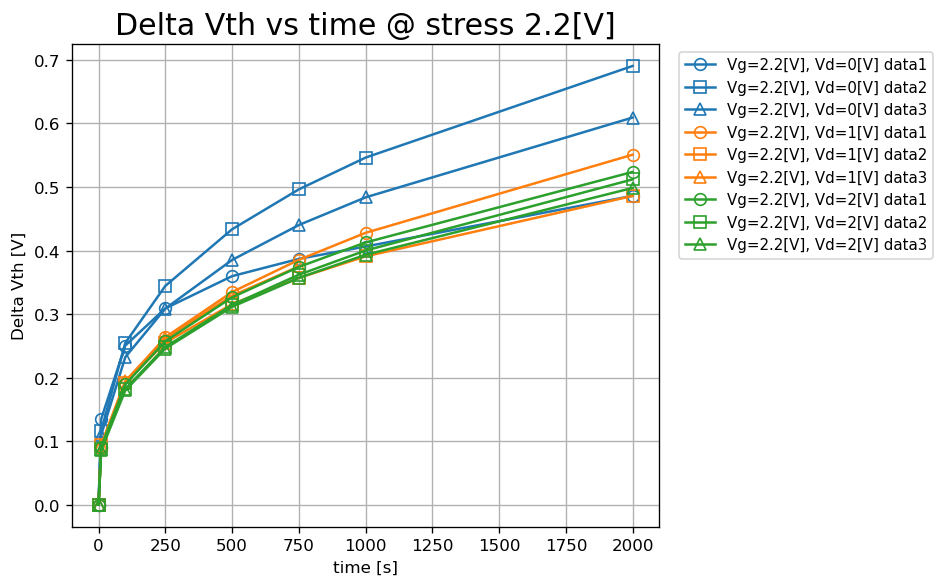

In [17]:
vd_color_map = {
    0: 'tab:blue',
    1: 'tab:orange',
    2: 'tab:green',
}

data_marker_map = {
    1: 'o',
    2: 's',
    3: '^',
}

plt.figure(figsize=(8, 5))

for result in results:
    delta_series = pd.Series(result["delta_vth_by_time"]).sort_index()
    line_color = vd_color_map.get(result["vd"], 'black')
    line_marker = data_marker_map.get(result["data_idx"], 'o')

    plt.plot(
        delta_series.index.to_numpy(),
        delta_series.to_numpy(),
        color=line_color,
        marker=line_marker,
        markerfacecolor='none',
        markersize=7,
        linewidth=1.5,
        label=result["label"],
    )

plt.xlabel('time [s]')
plt.ylabel('Delta Vth [V]')
plt.title('Delta Vth vs time @ stress 2.2[V]', fontsize=18)
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=9)
plt.tight_layout()
plt.show()


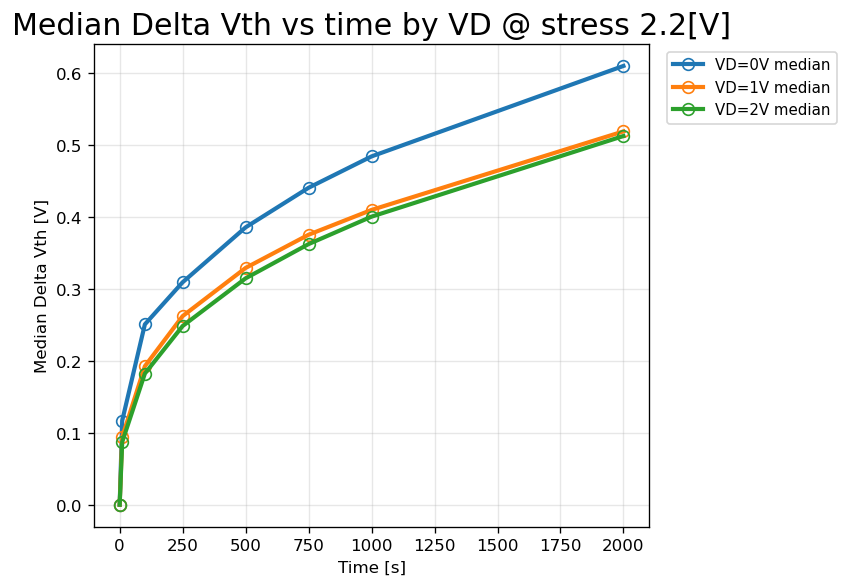

,vd,time_s,delta_vth
0,0,0,0.000000
1,0,10,0.116724
2,0,100,0.250448
3,0,250,0.308929
4,0,500,0.385169
5,0,750,0.440121
6,0,1000,0.483674
7,0,2000,0.609280
8,1,0,0.000000
9,1,10,0.093997


In [18]:
median_rows = []

for result in results:
    for time_s, delta_vth in result["delta_vth_by_time"].items():
        if pd.notna(delta_vth):
            median_rows.append({
                "vd": result["vd"],
                "time_s": time_s,
                "delta_vth": delta_vth,
            })

median_df = pd.DataFrame(median_rows)
median_df = median_df.groupby(["vd", "time_s"], as_index=False)["delta_vth"].median()

plt.figure(figsize=(7, 5))

for vd, group in median_df.groupby("vd"):
    group = group.sort_values("time_s")
    plt.plot(
        group["time_s"].to_numpy(),
        group["delta_vth"].to_numpy(),
        color=vd_color_map.get(vd, "black"),
        marker="o", markerfacecolor='none',
        linewidth=2.5,
        markersize=7,
        label=f"VD={vd}V median",
    )

plt.xlabel("Time [s]")
plt.ylabel("Median Delta Vth [V]")
plt.title("Median Delta Vth vs time by VD @ stress 2.2[V]", fontsize=18)
plt.grid(True, alpha=0.3)
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=9)
plt.tight_layout()
plt.show()

median_df


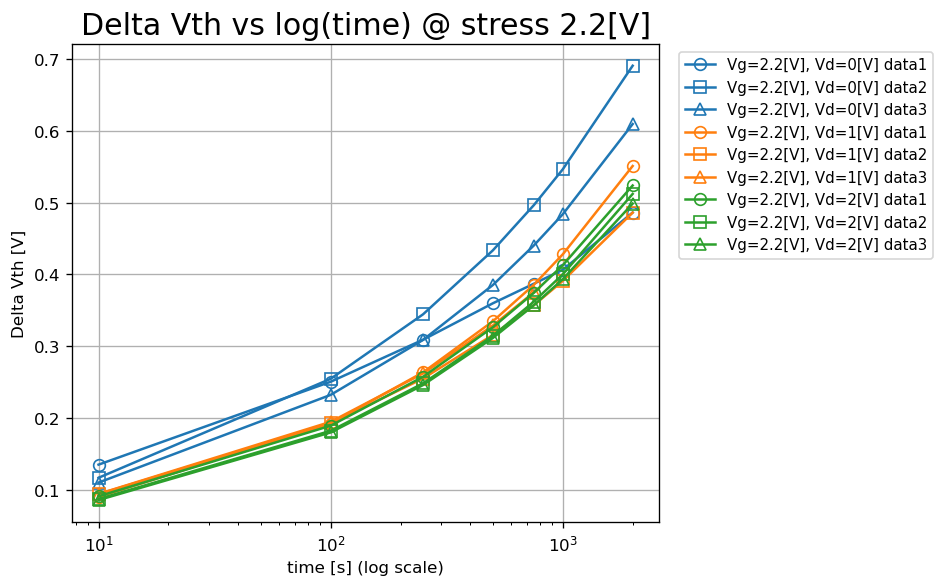

In [19]:
plt.figure(figsize=(8, 5))

for result in results:
    delta_series = pd.Series(result["delta_vth_by_time"]).sort_index()
    delta_series = delta_series[delta_series.index > 0]
    line_color = vd_color_map.get(result["vd"], 'black')
    line_marker = data_marker_map.get(result["data_idx"], 'o')

    plt.plot(
        delta_series.index.to_numpy(),
        delta_series.to_numpy(),
        color=line_color,
        marker=line_marker,
        markerfacecolor='none',
        markersize=7,
        linewidth=1.5,
        label=result["label"],
    )

plt.xscale('log')
plt.xlabel('time [s] (log scale)')
plt.ylabel('Delta Vth [V]')
plt.title('Delta Vth vs log(time) @ stress 2.2[V]', fontsize=18)
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=9)
plt.tight_layout()
plt.show()


In [20]:
all_times = sorted({time_s for result in results for time_s in result["delta_vth_by_time"].keys()})

summary_rows = []
for result in results:
    row = {
        "legend": result["label"],
        "stress_vg[V]": result["vg"],
        "stress_vd[V]": result["vd"],
        "initial_vth[V]": result["initial_vth"],
    }

    for time_s in all_times:
        row[f"delta_vth@{int(time_s)}s[V]"] = result["delta_vth_by_time"].get(time_s, np.nan)

    summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows)
summary_df = summary_df.sort_values(["stress_vd[V]", "legend"]).reset_index(drop=True)

display(summary_df.round(4))


,legend,stress_vg[V],stress_vd[V],initial_vth[V],delta_vth@0s[V],delta_vth@10s[V],delta_vth@100s[V],delta_vth@250s[V],delta_vth@500s[V],delta_vth@750s[V],delta_vth@1000s[V],delta_vth@2000s[V]
0,"Vg=2.2[V], Vd=0[V] data1",2.2,0,0.1563,0.0,0.1350,0.2504,0.3089,0.3597,0.3869,0.4063,0.4860
1,"Vg=2.2[V], Vd=0[V] data2",2.2,0,0.0782,0.0,0.1167,0.2545,0.3443,0.4334,0.4963,0.5463,0.6905
2,"Vg=2.2[V], Vd=0[V] data3",2.2,0,0.1410,0.0,0.1100,0.2321,0.3087,0.3852,0.4401,0.4837,0.6093
3,"Vg=2.2[V], Vd=1[V] data1",2.2,1,0.1555,0.0,0.0900,0.1923,0.2635,0.3347,0.3853,0.4279,0.5508
4,"Vg=2.2[V], Vd=1[V] data2",2.2,1,0.1909,0.0,0.0940,0.1923,0.2549,0.3156,0.3569,0.3908,0.4859
5,"Vg=2.2[V], Vd=1[V] data3",2.2,1,0.1932,0.0,0.0942,0.1946,0.2619,0.3288,0.3749,NaN,NaN
6,"Vg=2.2[V], Vd=2[V] data1",2.2,2,0.2064,0.0,0.0910,0.1892,0.2573,0.3264,0.3742,0.4127,0.5237
7,"Vg=2.2[V], Vd=2[V] data2",2.2,2,0.1968,0.0,0.0872,0.1821,0.2482,0.3144,0.3619,0.4000,0.5120
8,"Vg=2.2[V], Vd=2[V] data3",2.2,2,0.2216,0.0,0.0857,0.1798,0.2458,0.3114,0.3570,0.3933,0.4985


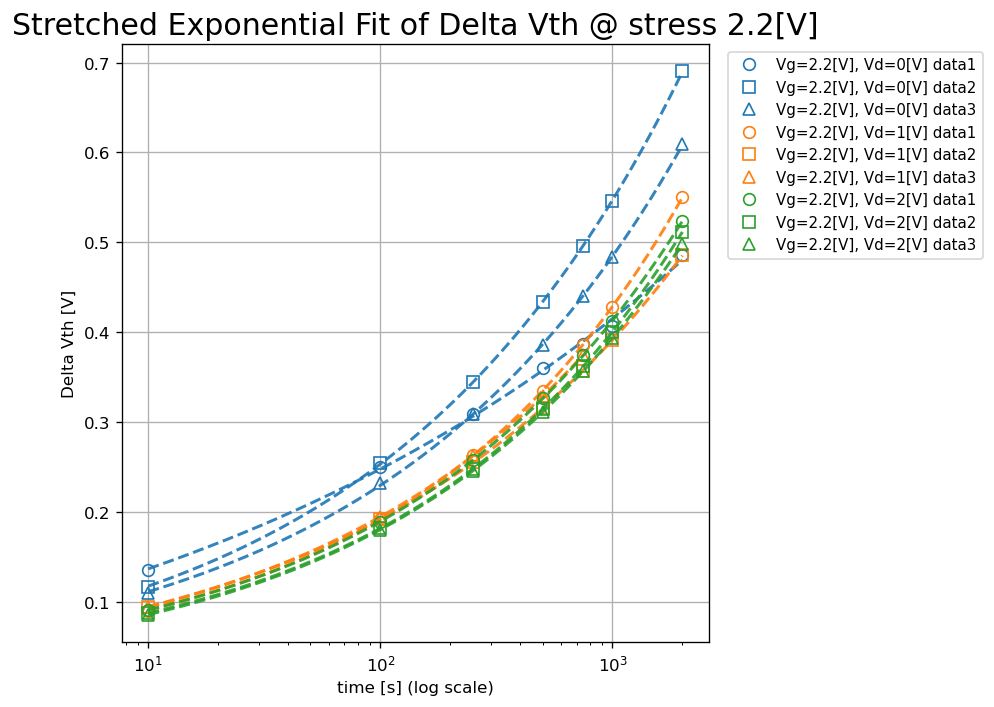

,legend,stress_vg[V],stress_vd[V],data_idx,V_pre[V],tau[s],beta,V_inf[V],fit_rmse[V]
0,"Vg=2.2[V], Vd=0[V] data1",2.2,0,1,15.6478,1.628502e+11,0.1819,15.5684,0.0045
1,"Vg=2.2[V], Vd=0[V] data2",2.2,0,2,334.2116,2.078459e+11,0.3349,334.2119,0.0007
2,"Vg=2.2[V], Vd=0[V] data3",2.2,0,3,282.1811,2.072086e+11,0.3334,282.1896,0.0013
3,"Vg=2.2[V], Vd=1[V] data1",2.2,1,1,357.9980,7.753049e+10,0.3725,358.0145,0.0009
4,"Vg=2.2[V], Vd=1[V] data2",2.2,1,2,173.6047,2.998933e+11,0.3125,173.6066,0.0006
5,"Vg=2.2[V], Vd=1[V] data3",2.2,1,3,3.1364,2.609038e+05,0.3590,3.1502,0.0001
6,"Vg=2.2[V], Vd=2[V] data1",2.2,2,1,6.3144,1.684674e+06,0.3681,6.3305,0.0002
7,"Vg=2.2[V], Vd=2[V] data2",2.2,2,2,333.1418,1.070397e+11,0.3658,333.1578,0.0004
8,"Vg=2.2[V], Vd=2[V] data3",2.2,2,3,4.2311,5.928313e+05,0.3702,4.2450,0.0003


In [21]:
def stretched_exponential(t, v_pre, tau, beta, v_inf):
    return -v_pre * np.exp(-((t / tau) ** beta)) + v_inf


fit_rows = []

plt.figure(figsize=(8, 6))

for result in results:
    delta_series = pd.Series(result["delta_vth_by_time"]).sort_index()
    delta_series = delta_series[(delta_series.index > 0) & (~delta_series.isna())]

    line_color = vd_color_map.get(result["vd"], 'black')
    line_marker = data_marker_map.get(result["data_idx"], 'o')

    fit_row = {
        "legend": result["label"],
        "stress_vg[V]": result["vg"],
        "stress_vd[V]": result["vd"],
        "data_idx": result["data_idx"],
        "V_pre[V]": np.nan,
        "tau[s]": np.nan,
        "beta": np.nan,
        "V_inf[V]": np.nan,
        "fit_rmse[V]": np.nan,
    }

    if len(delta_series) >= 4:
        x_data = delta_series.index.to_numpy(dtype=float)
        y_data = delta_series.to_numpy(dtype=float)

        v_inf_guess = float(np.nanmax(y_data))
        v_pre_guess = float(max(v_inf_guess - y_data[0], 1e-6))
        tau_guess = float(np.median(x_data))
        beta_guess = 0.5

        lower_bounds = [0.0, 1e-12, 0.0, -np.inf]
        upper_bounds = [np.inf, np.inf, 2.0, np.inf]

        try:
            popt, _ = curve_fit(
                stretched_exponential,
                x_data,
                y_data,
                p0=[v_pre_guess, tau_guess, beta_guess, v_inf_guess],
                bounds=(lower_bounds, upper_bounds),
                maxfev=20000,
            )

            y_fit = stretched_exponential(x_data, *popt)
            rmse = float(np.sqrt(np.mean((y_data - y_fit) ** 2)))

            fit_row["V_pre[V]"] = popt[0]
            fit_row["tau[s]"] = popt[1]
            fit_row["beta"] = popt[2]
            fit_row["V_inf[V]"] = popt[3]
            fit_row["fit_rmse[V]"] = rmse

            x_fit = np.logspace(np.log10(x_data.min()), np.log10(x_data.max()), 300)
            y_fit_dense = stretched_exponential(x_fit, *popt)

            plt.plot(
                x_fit,
                y_fit_dense,
                color=line_color,
                linestyle='--',
                linewidth=1.8,
                alpha=0.9,
            )
        except RuntimeError:
            pass

    plt.plot(
        delta_series.index.to_numpy(),
        delta_series.to_numpy(),
        linestyle='None',
        color=line_color,
        marker=line_marker,
        markerfacecolor='none',
        markersize=7,
        label=result["label"],
    )

    fit_rows.append(fit_row)

plt.xscale('log')
plt.xlabel('time [s] (log scale)')
plt.ylabel('Delta Vth [V]')
plt.title('Stretched Exponential Fit of Delta Vth @ stress 2.2[V]', fontsize=18)
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=9)
plt.tight_layout()
plt.show()

fit_df = pd.DataFrame(fit_rows)
fit_df = fit_df.sort_values(["stress_vd[V]", "data_idx"]).reset_index(drop=True)
display(fit_df.round(4))


In [22]:
all_ss_times = sorted({time_s for result in results for time_s in result["ss_by_time"].keys()})

ss_rows = []
for result in results:
    row = {
        "legend": result["label"],
        "stress_vg[V]": result["vg"],
        "stress_vd[V]": result["vd"],
    }

    for time_s in all_ss_times:
        row[f"ss@{int(time_s)}s[mV/dec]"] = result["ss_by_time"].get(time_s, np.nan)

    ss_rows.append(row)

ss_df = pd.DataFrame(ss_rows)
ss_df = ss_df.sort_values(["stress_vd[V]", "legend"]).reset_index(drop=True)
display(ss_df.round(4))


,legend,stress_vg[V],stress_vd[V],ss@0s[mV/dec],ss@10s[mV/dec],ss@100s[mV/dec],ss@250s[mV/dec],ss@500s[mV/dec],ss@750s[mV/dec],ss@1000s[mV/dec],ss@2000s[mV/dec]
0,"Vg=2.2[V], Vd=0[V] data1",2.2,0,138.2958,141.1329,147.4168,150.4042,152.2552,151.5790,154.1015,153.5133
1,"Vg=2.2[V], Vd=0[V] data2",2.2,0,134.5805,139.7223,144.7700,146.1105,146.6502,146.8352,146.3423,145.2438
2,"Vg=2.2[V], Vd=0[V] data3",2.2,0,131.2627,135.5181,141.4146,143.8302,146.1504,146.4643,146.2040,145.5387
3,"Vg=2.2[V], Vd=1[V] data1",2.2,1,128.9924,132.0764,137.5796,138.4918,140.1930,140.1973,139.3788,137.0798
4,"Vg=2.2[V], Vd=1[V] data2",2.2,1,129.0988,130.8042,135.7296,138.3395,138.2896,140.2863,139.7817,140.1528
5,"Vg=2.2[V], Vd=1[V] data3",2.2,1,127.6531,128.9073,133.9834,135.3618,136.8456,136.8560,NaN,NaN
6,"Vg=2.2[V], Vd=2[V] data1",2.2,2,126.4839,128.2810,132.4522,133.0717,134.8079,134.9431,133.9943,134.3612
7,"Vg=2.2[V], Vd=2[V] data2",2.2,2,127.4574,128.2802,132.7125,135.4499,135.6755,135.7607,136.6215,134.8840
8,"Vg=2.2[V], Vd=2[V] data3",2.2,2,124.8848,127.1246,131.1325,131.4772,133.6611,133.6119,132.9204,133.1738


In [23]:
all_mu_times = sorted({time_s for result in results for time_s in result["mobility_by_time"].keys()})

mu_rows = []
for result in results:
    vd_values_used = [v for v in result["vd_used_by_time"].values() if not np.isnan(v)]
    row = {
        "legend": result["label"],
        "stress_vg[V]": result["vg"],
        "stress_vd[V]": result["vd"],
        "Cox_total[pF]": Cox_total_F * 1e12,
        "mu_calc_vd[V]": vd_values_used[0] if len(vd_values_used) > 0 else np.nan,
    }

    for time_s in all_mu_times:
        row[f"mu@{int(time_s)}s[cm^2/Vs]"] = result["mobility_by_time"].get(time_s, np.nan)

    mu_rows.append(row)

mu_df = pd.DataFrame(mu_rows)
mu_df = mu_df.sort_values(["stress_vd[V]", "legend"]).reset_index(drop=True)
display(mu_df.round(4))


,legend,stress_vg[V],stress_vd[V],Cox_total[pF],mu_calc_vd[V],mu@0s[cm^2/Vs],mu@10s[cm^2/Vs],mu@100s[cm^2/Vs],mu@250s[cm^2/Vs],mu@500s[cm^2/Vs],mu@750s[cm^2/Vs],mu@1000s[cm^2/Vs],mu@2000s[cm^2/Vs]
0,"Vg=2.2[V], Vd=0[V] data1",2.2,0,4.25,0.1,9.7958,10.1826,10.1252,10.0273,9.9501,9.8786,9.8372,9.6734
1,"Vg=2.2[V], Vd=0[V] data2",2.2,0,4.25,0.1,10.0141,10.4141,10.3228,10.1572,10.0028,9.8805,9.7638,9.2749
2,"Vg=2.2[V], Vd=0[V] data3",2.2,0,4.25,0.1,9.9153,10.3021,10.2268,10.0951,9.9407,9.8372,9.7600,9.4682
3,"Vg=2.2[V], Vd=1[V] data1",2.2,1,4.25,0.1,9.9040,10.2155,10.2127,10.1365,10.0348,9.9520,9.8654,9.6659
4,"Vg=2.2[V], Vd=1[V] data2",2.2,1,4.25,0.1,9.8296,10.1233,10.1252,10.0593,9.9765,9.9068,9.8315,9.6602
5,"Vg=2.2[V], Vd=1[V] data3",2.2,1,4.25,0.1,9.8080,10.0913,10.0951,10.0179,8.9769,9.7600,0.0019,0.0001
6,"Vg=2.2[V], Vd=2[V] data1",2.2,2,4.25,0.1,9.8456,10.1308,10.1365,10.0593,9.9784,9.9162,9.8616,9.6471
7,"Vg=2.2[V], Vd=2[V] data2",2.2,2,4.25,0.1,9.8701,10.1591,10.1647,10.0913,10.0141,9.9275,9.8824,9.6659
8,"Vg=2.2[V], Vd=2[V] data3",2.2,2,4.25,0.1,9.8409,10.1120,10.1139,10.0687,9.9727,9.8936,9.8786,9.5962
